# Knapsack GA Batch Analysis

Simple analysis of knapsack GA batch results.

## Imports and setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re
import itertools
import ipywidgets as W
from IPython.display import display, clear_output

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## Load results

In [91]:
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p/'AGChallenge.sln').exists() or (p/'.git').exists() or (p/'CMakeLists.txt').exists():
            return p
    return start

project_root = find_project_root(Path.cwd().resolve())

results_csv = (project_root / 'examples' / 'knap_batch_large_pilot_results.csv')  # <-- input csv

assert results_csv.exists(), f"Results CSV not found: {results_csv}"
print(results_csv)

dtypes = {
    'run': 'Int64',
    'problem': 'string',
    'pop': 'Int64',
    'pc': 'float64',
    'pm': 'float64',
    'seconds': 'float64',
    'fitness': 'float64',
    'instance': 'string',
    'generations': 'Int64',
    'evaluations': 'Int64',
    'seed': 'Int64',
}

raw = pd.read_csv(results_csv, dtype=dtypes)
raw['source_path'] = str(results_csv)
raw.head()

/home/razuer/projects/AGChallenge/examples/knap_batch_large_pilot_results.csv


,run,problem,pop,pc,pm,seconds,fitness,instance,generations,evaluations,seed,source_path
0,1,knap,400,0.90,0.0002,20.0,0.427781,instances_01_KP/large_scale/knapPI_3_5000_1000_1,183,71159,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
1,2,knap,400,0.90,0.0002,20.0,0.429626,instances_01_KP/large_scale/knapPI_3_5000_1000_1,186,72183,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
2,3,knap,400,0.90,0.0002,20.0,0.430256,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,73534,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
3,4,knap,400,0.95,0.0002,20.0,0.429666,instances_01_KP/large_scale/knapPI_3_5000_1000_1,182,71886,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
4,5,knap,400,0.95,0.0002,20.0,0.431182,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,75091,<NA>,/home/razuer/projects/AGChallenge/examples/kna...


## Clean and type conversions

In [92]:
df = raw.copy()
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
num_cols = ['run','pop','pc','pm','seconds','fitness','generations','evaluations']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(how='all')
crit = ['fitness','pm','pc','pop','generations']
df = df.dropna(subset=[c for c in crit if c in df.columns])
df['seed'] = df.get('seed').astype('Int64')
df.head()

,run,problem,pop,pc,pm,seconds,fitness,instance,generations,evaluations,seed,source_path
0,1,knap,400,0.90,0.0002,20.0,0.427781,instances_01_KP/large_scale/knapPI_3_5000_1000_1,183,71159,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
1,2,knap,400,0.90,0.0002,20.0,0.429626,instances_01_KP/large_scale/knapPI_3_5000_1000_1,186,72183,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
2,3,knap,400,0.90,0.0002,20.0,0.430256,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,73534,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
3,4,knap,400,0.95,0.0002,20.0,0.429666,instances_01_KP/large_scale/knapPI_3_5000_1000_1,182,71886,<NA>,/home/razuer/projects/AGChallenge/examples/kna...
4,5,knap,400,0.95,0.0002,20.0,0.431182,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,75091,<NA>,/home/razuer/projects/AGChallenge/examples/kna...


## Derive columns

In [93]:
sp = pd.Series(df['source_path']).apply(Path)
df['batch_filename'] = sp.apply(lambda p: p.name.replace('_results.csv',''))
df['instance_name'] = df['instance'].astype('string').apply(lambda s: Path(str(s)).name if pd.notna(s) else s)
df['pc_r'] = df['pc'].round(3)
df['pm_r'] = df['pm'].round(3)
df['param_key'] = 'pop=' + df['pop'].astype('Int64').astype('string') + '|pc=' + df['pc_r'].astype(str) + '|pm=' + df['pm_r'].astype(str)
df.head()

,run,problem,pop,pc,pm,seconds,fitness,instance,generations,evaluations,seed,source_path,batch_filename,instance_name,pc_r,pm_r,param_key
0,1,knap,400,0.90,0.0002,20.0,0.427781,instances_01_KP/large_scale/knapPI_3_5000_1000_1,183,71159,<NA>,/home/razuer/projects/AGChallenge/examples/kna...,knap_batch_large_pilot,knapPI_3_5000_1000_1,0.90,0.0,pop=400|pc=0.9|pm=0.0
1,2,knap,400,0.90,0.0002,20.0,0.429626,instances_01_KP/large_scale/knapPI_3_5000_1000_1,186,72183,<NA>,/home/razuer/projects/AGChallenge/examples/kna...,knap_batch_large_pilot,knapPI_3_5000_1000_1,0.90,0.0,pop=400|pc=0.9|pm=0.0
2,3,knap,400,0.90,0.0002,20.0,0.430256,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,73534,<NA>,/home/razuer/projects/AGChallenge/examples/kna...,knap_batch_large_pilot,knapPI_3_5000_1000_1,0.90,0.0,pop=400|pc=0.9|pm=0.0
3,4,knap,400,0.95,0.0002,20.0,0.429666,instances_01_KP/large_scale/knapPI_3_5000_1000_1,182,71886,<NA>,/home/razuer/projects/AGChallenge/examples/kna...,knap_batch_large_pilot,knapPI_3_5000_1000_1,0.95,0.0,pop=400|pc=0.95|pm=0.0
4,5,knap,400,0.95,0.0002,20.0,0.431182,instances_01_KP/large_scale/knapPI_3_5000_1000_1,190,75091,<NA>,/home/razuer/projects/AGChallenge/examples/kna...,knap_batch_large_pilot,knapPI_3_5000_1000_1,0.95,0.0,pop=400|pc=0.95|pm=0.0


## EDA

In [94]:
print(df.shape)
df.head()
df.describe(include='all')
print('instances:', sorted(df['instance_name'].dropna().unique().tolist()))
print('pops:', sorted(df['pop'].dropna().unique().tolist()))
print('pcs:', sorted(df['pc_r'].dropna().unique().tolist()))
print('pms:', sorted(df['pm_r'].dropna().unique().tolist()))
df.groupby('batch_filename').size()

(9, 17)
instances: ['knapPI_3_5000_1000_1']
pops: [400, 800]
pcs: [0.9, 0.95]
pms: [0.0]


batch_filename
knap_batch_large_pilot    9
dtype: int64

## Aggregate metrics

In [95]:
g = (df.groupby(['batch_filename','instance_name','pop','pc_r','pm_r'])
      .agg(fitness_mean=('fitness','mean'),
           fitness_std=('fitness','std'),
           fitness_min=('fitness','min'),
           fitness_max=('fitness','max'),
           seconds_mean=('seconds','mean'),
           generations_mean=('generations','mean'),
           evaluations_mean=('evaluations','mean'),
           n=('run','count'))
      .reset_index())
g['ci95'] = np.where(g['n']>1, 1.96 * g['fitness_std'] / np.sqrt(g['n']), np.nan)
# add param_key for plotting
pc_str = g['pc_r'].map(lambda x: f"{x:.3f}")
pm_str = g['pm_r'].map(lambda x: f"{x:.3f}")
g['param_key'] = 'pop=' + g['pop'].astype('Int64').astype('string') + '|pc=' + pc_str + '|pm=' + pm_str
g.head()

,batch_filename,instance_name,pop,pc_r,pm_r,fitness_mean,fitness_std,fitness_min,fitness_max,seconds_mean,generations_mean,evaluations_mean,n,ci95,param_key
0,knap_batch_large_pilot,knapPI_3_5000_1000_1,400,0.90,0.0,0.429221,0.001286,0.427781,0.430256,20.0,186.333333,72292.0,3,0.001456,pop=400|pc=0.900|pm=0.000
1,knap_batch_large_pilot,knapPI_3_5000_1000_1,400,0.95,0.0,0.429968,0.001095,0.429055,0.431182,20.0,186.333333,73590.666667,3,0.001239,pop=400|pc=0.950|pm=0.000
2,knap_batch_large_pilot,knapPI_3_5000_1000_1,800,0.90,0.0,0.425102,0.000243,0.424909,0.425375,20.0,92.333333,71958.666667,3,0.000275,pop=800|pc=0.900|pm=0.000


## Plotting

### Plot: fitness by pm

PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_fitness_by_pm.png')

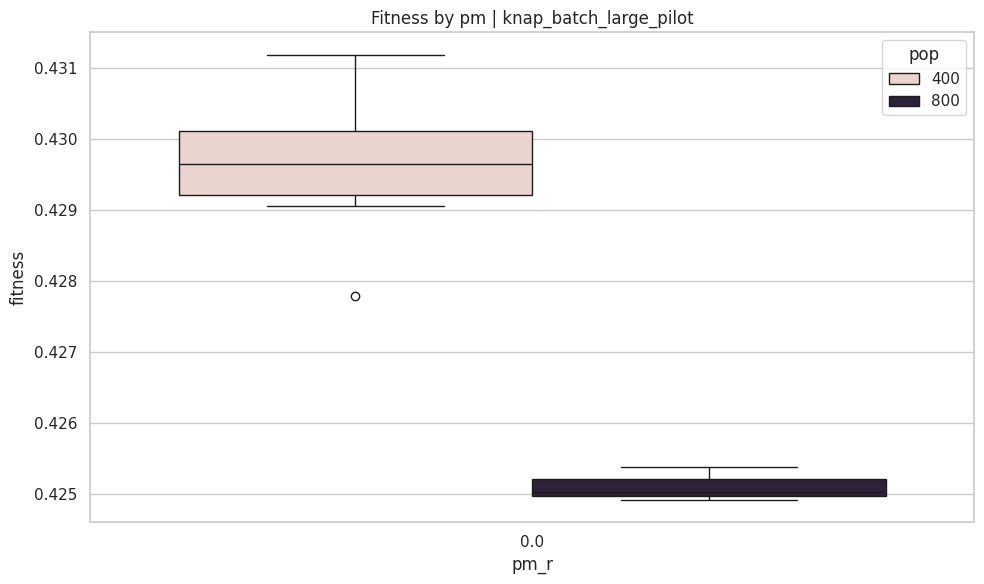

In [96]:
plots_dir = (project_root / 'analysis' / 'plots')
plots_dir.mkdir(parents=True, exist_ok=True)

batch0 = df['batch_filename'].iloc[0]
df0 = df[df['batch_filename']==batch0]
plt.figure(figsize=(10,6))
sns.boxplot(data=df0, x='pm_r', y='fitness', hue='pop')
plt.title(f'Fitness by pm | {batch0}')
plt.tight_layout()
fig_path = plots_dir / f'{batch0}_fitness_by_pm.png'
plt.savefig(fig_path, dpi=150)
fig_path

### Plot: fitness vs generations

PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_fitness_vs_generations.png')

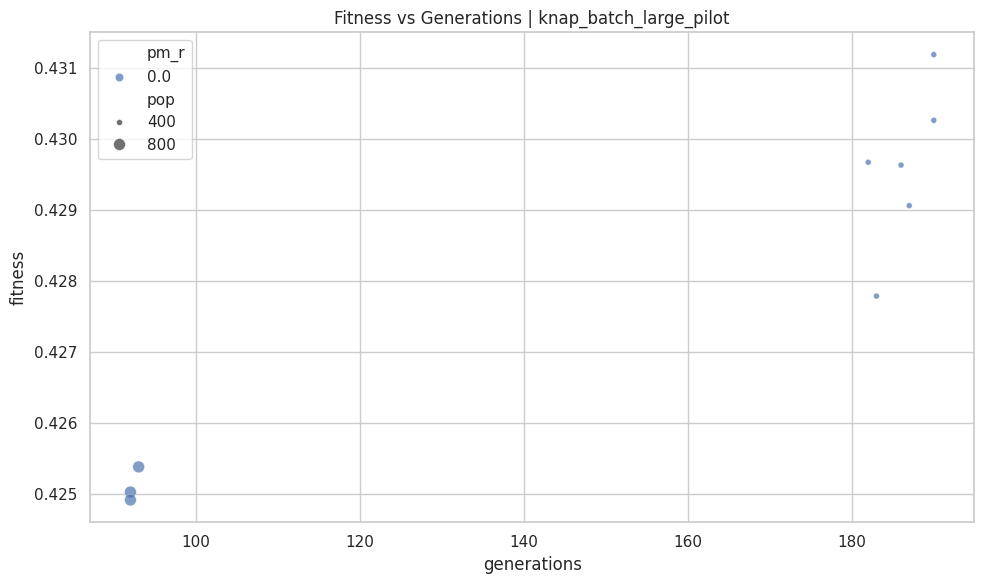

In [97]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df0, x='generations', y='fitness', hue='pm_r', size='pop', alpha=0.7)
plt.title(f'Fitness vs Generations | {batch0}')
plt.tight_layout()
fig_path = plots_dir / f'{batch0}_fitness_vs_generations.png'
plt.savefig(fig_path, dpi=150)
fig_path

### Plot: top configs by mean fitness

PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_mean_fitness_topN.png')

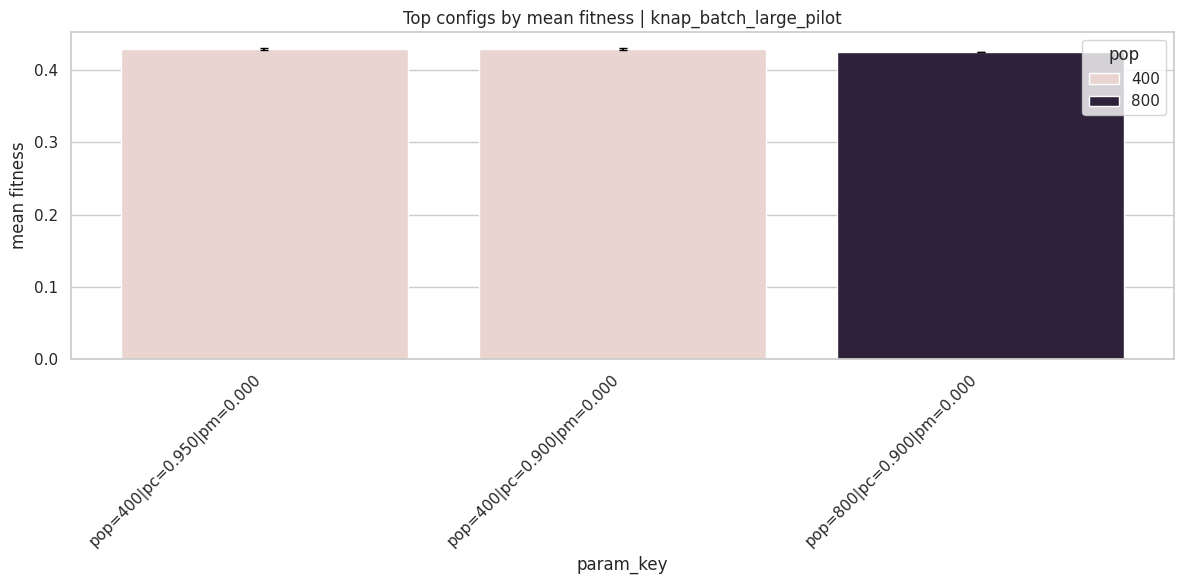

In [98]:
g_sorted = g.sort_values('fitness_mean', ascending=False)
top = g_sorted.head(20)
plt.figure(figsize=(12,6))
sns.barplot(data=top, x='param_key', y='fitness_mean', hue='pop', errorbar=None)
for i, row in top.reset_index().iterrows():
    if not pd.isna(row['ci95']):
        plt.errorbar(i, row['fitness_mean'], yerr=row['ci95'], fmt='none', ecolor='black', capsize=3)
plt.xticks(rotation=45, ha='right')
plt.ylabel('mean fitness')
plt.title(f'Top configs by mean fitness | {batch0}')
plt.tight_layout()
fig_path = plots_dir / f'{batch0}_mean_fitness_topN.png'
plt.savefig(fig_path, dpi=150)
fig_path

### Plot: heatmap pc x pm (fixed pop)

PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_heatmap_pc_pm_pop400.png')

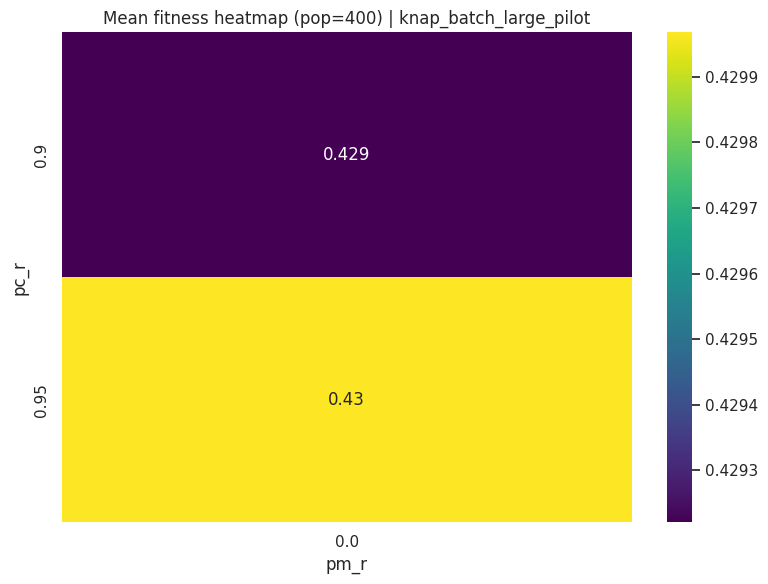

In [99]:
sel_pop = df0['pop'].mode().iloc[0]
sub = g[(g['batch_filename']==batch0) & (g['pop']==sel_pop)]
piv = sub.pivot_table(index='pc_r', columns='pm_r', values='fitness_mean')
plt.figure(figsize=(8,6))
sns.heatmap(piv, annot=True, fmt='.3g', cmap='viridis')
plt.title(f'Mean fitness heatmap (pop={sel_pop}) | {batch0}')
plt.tight_layout()
fig_path = plots_dir / f'{batch0}_heatmap_pc_pm_pop{sel_pop}.png'
plt.savefig(fig_path, dpi=150)
fig_path

### Plot: runtime vs evaluations

PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_runtime_vs_evaluations.png')

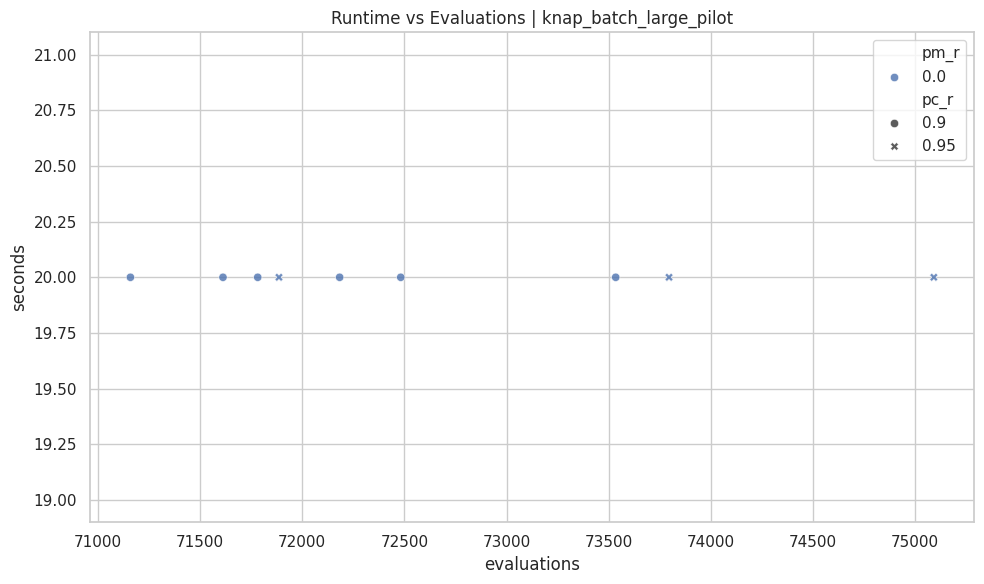

In [100]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df0, x='evaluations', y='seconds', hue='pm_r', style='pc_r', alpha=0.8)
plt.title(f'Runtime vs Evaluations | {batch0}')
plt.tight_layout()
fig_path = plots_dir / f'{batch0}_runtime_vs_evaluations.png'
plt.savefig(fig_path, dpi=150)
fig_path

In [101]:
plots_dir.mkdir(parents=True, exist_ok=True)
sum_path = plots_dir / f'{batch0}_summary.csv'
g.to_csv(sum_path, index=False)
clean_path = plots_dir / f'{batch0}_clean.csv'
df0.to_csv(clean_path, index=False)
sum_path, clean_path

(PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_summary.csv'),
 PosixPath('/home/razuer/projects/AGChallenge/analysis/plots/knap_batch_large_pilot_clean.csv'))